# Credit Card Fraud & Customer Spending Analysis

In this project I analyse credit card transactions to find out:
1. When and where fraud happens most
2. Which customers spend the most
3. Whether a simple model can predict fraud
4. Whether an offer campaign increased customer spending

**Tools used:** Python, Pandas, Matplotlib, Scikit-learn, SciPy

**Note:** The data is synthetic (created by me for practice), so the numbers are not from a real bank.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

plt.rcParams['figure.figsize'] = (8, 4)

## 2. Load the data

In [3]:
tx = pd.read_csv('data/transactions.csv', parse_dates=['timestamp'])
customers = pd.read_csv('data/customers.csv')
campaign = pd.read_csv('data/campaign.csv')

print('Transactions:', tx.shape)
print('Customers:', customers.shape)
print('Campaign:', campaign.shape)
tx.head()

Transactions: (150250, 9)
Customers: (5000, 4)
Campaign: (5000, 5)


,txn_id,customer_id,timestamp,category,channel,amount,international,merchant_risk,is_fraud
0,8838,4692,2026-07-28 18:12:00,Entertainment,POS,653.22,False,0.152,0
1,15598,2481,2026-01-20 15:55:00,Utilities,POS,1179.54,False,0.043,0
2,79638,2617,2026-07-13 22:40:00,Entertainment,POS,558.43,False,0.190,0
3,81711,4970,2026-06-08 13:50:00,Utilities,POS,1285.19,False,0.008,0
4,19324,1938,2026-01-01 06:00:00,Utilities,Online,501.88,False,0.062,0


## 3. Data cleaning

In [4]:
# check missing values and duplicates
print(tx.isnull().sum())
print()
print('Duplicate rows:', tx.duplicated().sum())

txn_id             0
customer_id        0
timestamp          0
category           0
channel          300
amount           604
international      0
merchant_risk      0
is_fraud           0
dtype: int64

Duplicate rows: 250


There are duplicate rows, some missing amounts and some missing channels. My plan:
- Drop duplicate rows
- Fill missing amount with the median amount of that category (median is better than mean because amounts are skewed)
- Fill missing channel with 'Unknown'

In [5]:
tx = tx.drop_duplicates()
tx['amount'] = tx.groupby('category')['amount'].transform(lambda x: x.fillna(x.median()))
tx['channel'] = tx['channel'].fillna('Unknown')

# new columns for analysis
tx['hour'] = tx['timestamp'].dt.hour
tx['month'] = tx['timestamp'].dt.to_period('M').astype(str)

print('Rows after cleaning:', len(tx))
print('Missing values left:', tx.isnull().sum().sum())

Rows after cleaning: 150000
Missing values left: 0


## 4. Exploratory analysis: where does fraud happen?

In [7]:
fraud_rate = tx['is_fraud'].mean() * 100
print(f'Overall fraud rate: {fraud_rate:.2f}%')
print('Total fraud transactions:', tx['is_fraud'].sum())

Overall fraud rate: 0.88%
Total fraud transactions: 1324


Fraud is very rare (less than 1%), so the data is highly imbalanced. This matters later when I build the model.

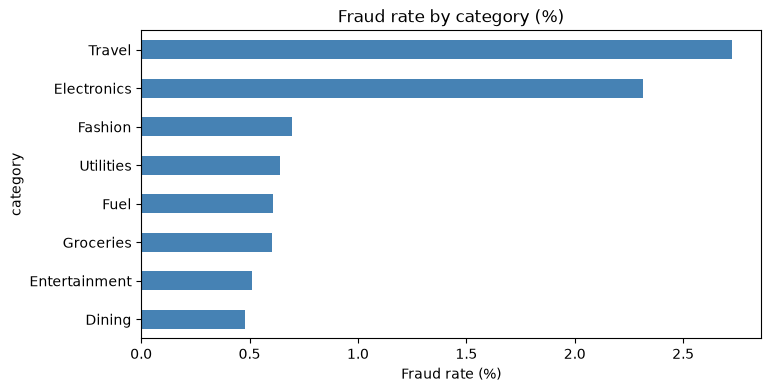

category
Dining           0.48
Entertainment    0.51
Groceries        0.61
Fuel             0.61
Utilities        0.64
Fashion          0.70
Electronics      2.31
Travel           2.72
Name: is_fraud, dtype: float64


In [8]:
# fraud rate by category
cat_fraud = (tx.groupby('category')['is_fraud'].mean() * 100).sort_values()
cat_fraud.plot(kind='barh', color='steelblue')
plt.title('Fraud rate by category (%)')
plt.xlabel('Fraud rate (%)')
plt.show()
print(cat_fraud.round(2))

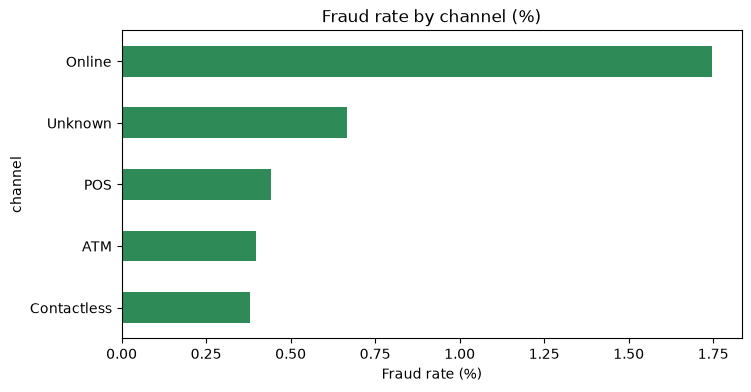

channel
Contactless    0.38
ATM            0.40
POS            0.44
Unknown        0.67
Online         1.75
Name: is_fraud, dtype: float64


In [9]:
# fraud rate by channel
ch_fraud = (tx.groupby('channel')['is_fraud'].mean() * 100).sort_values()
ch_fraud.plot(kind='barh', color='seagreen')
plt.title('Fraud rate by channel (%)')
plt.xlabel('Fraud rate (%)')
plt.show()
print(ch_fraud.round(2))

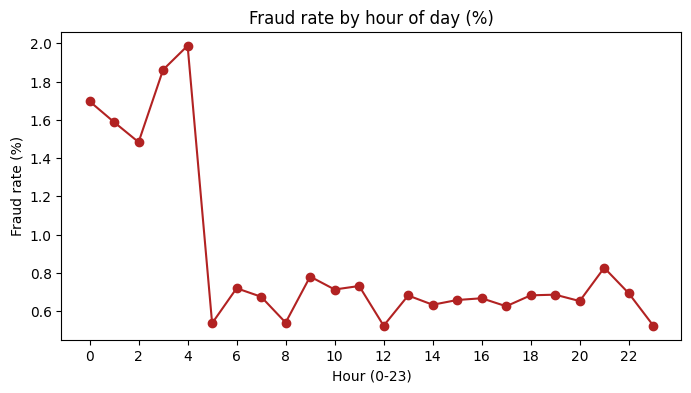

In [8]:
# fraud rate by hour of the day
hour_fraud = tx.groupby('hour')['is_fraud'].mean() * 100
plt.plot(hour_fraud.index, hour_fraud.values, marker='o', color='firebrick')
plt.title('Fraud rate by hour of day (%)')
plt.xlabel('Hour (0-23)')
plt.ylabel('Fraud rate (%)')
plt.xticks(range(0, 24, 2))
plt.show()

In [9]:
# international vs domestic
intl = tx.groupby('international')['is_fraud'].mean() * 100
print('Domestic fraud rate:', round(intl[False], 2), '%')
print('International fraud rate:', round(intl[True], 2), '%')

Domestic fraud rate: 0.68 %
International fraud rate: 5.06 %


## 5. Customer spending analysis

In [10]:
# total spend per customer
spend = tx.groupby('customer_id')['amount'].sum().sort_values(ascending=False)

# how much do the top 20% customers contribute?
top_n = int(len(spend) * 0.2)
top_share = spend.head(top_n).sum() / spend.sum() * 100
print(f'Top 20% customers contribute {top_share:.1f}% of total spend')

Top 20% customers contribute 39.9% of total spend


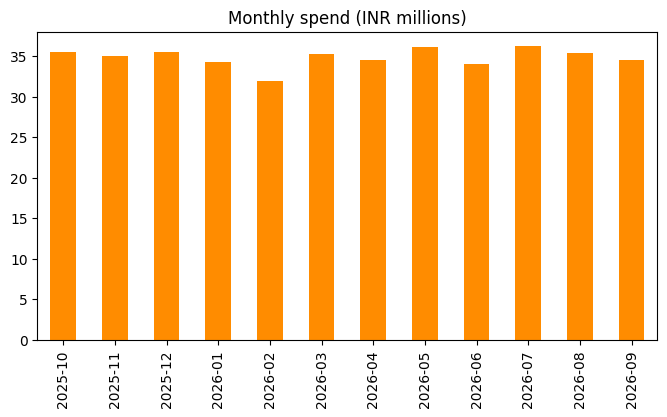

In [11]:
# monthly spend trend
monthly = tx.groupby('month')['amount'].sum() / 1_000_000
monthly.plot(kind='bar', color='darkorange')
plt.title('Monthly spend (INR millions)')
plt.xlabel('')
plt.show()

In [12]:
# spend by city tier
spend_df = spend.reset_index().merge(customers, on='customer_id')
print(spend_df.groupby('city_tier')['amount'].mean().round(0))

city_tier
Tier 1    83912.0
Tier 2    82181.0
Tier 3    85975.0
Name: amount, dtype: float64


## 6. Fraud prediction model

I used **Logistic Regression** because it is simple and easy to explain. Since fraud is very rare, I used `class_weight='balanced'` so the model pays attention to the fraud cases. I also look at precision and recall, not just accuracy, because a model that says 'no fraud' every time would still be 99% accurate.

In [13]:
data = tx.merge(customers, on='customer_id')
data['night'] = data['hour'].between(0, 4).astype(int)
data['log_amount'] = np.log1p(data['amount'])
data['international'] = data['international'].astype(int)

features = ['log_amount', 'night', 'international', 'merchant_risk',
            'age', 'tenure_months', 'category', 'channel', 'city_tier']
X = pd.get_dummies(data[features], drop_first=True)
y = data['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [14]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_s, y_train)

pred = model.predict(X_test_s)
prob = model.predict_proba(X_test_s)[:, 1]

print(classification_report(y_test, pred))
print('ROC-AUC:', round(roc_auc_score(y_test, prob), 3))
print('Confusion matrix:')
print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.78      0.87     37169
           1       0.03      0.69      0.05       331

    accuracy                           0.77     37500
   macro avg       0.51      0.73      0.46     37500
weighted avg       0.99      0.77      0.86     37500

ROC-AUC: 0.811
Confusion matrix:
[[28828  8341]
 [  104   227]]


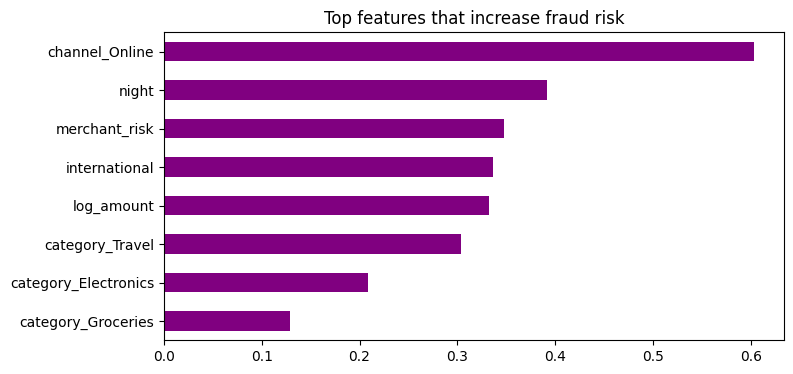

In [15]:
# which features matter most?
coef = pd.Series(model.coef_[0], index=X.columns).sort_values()
coef.tail(8).plot(kind='barh', color='purple')
plt.title('Top features that increase fraud risk')
plt.show()

## 7. Offer campaign: did it work? (A/B test)

Customers were randomly split into a control group (no offer) and a treatment group (got an offer). I compare their spending after the campaign using a t-test.
- H0: there is no difference in average spend between the groups
- H1: there is a difference

In [16]:
control = campaign[campaign['group'] == 'control']['post_spend']
treatment = campaign[campaign['group'] == 'treatment']['post_spend']

print('Control average spend:', round(control.mean()))
print('Treatment average spend:', round(treatment.mean()))

t_stat, p_value = stats.ttest_ind(treatment, control, equal_var=False)
lift = (treatment.mean() - control.mean()) / control.mean() * 100
print(f'Lift: {lift:.1f}%')
print('p-value:', round(p_value, 4))

Control average spend: 25261
Treatment average spend: 26382
Lift: 4.4%
p-value: 0.0456


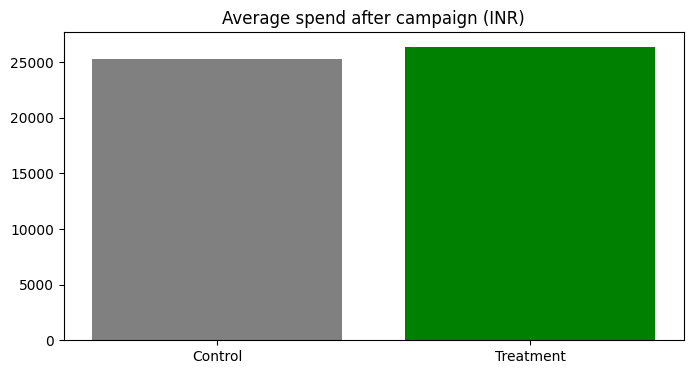

In [17]:
plt.bar(['Control', 'Treatment'], [control.mean(), treatment.mean()],
        color=['grey', 'green'])
plt.title('Average spend after campaign (INR)')
plt.show()

## 8. Conclusions

**Fraud patterns**
- Overall fraud rate is 0.88% (1,324 fraud transactions out of 150,000).
- International transactions have a much higher fraud rate (5.06%) than domestic ones (0.68%).
- Travel (2.72%) and Electronics (2.31%) are the riskiest categories, and Online is the riskiest channel (1.75%).
- Fraud is higher during late night hours (12am to 4am).

**Customers**
- The top 20% of customers contribute about 40% of total spend.
- Average spend is similar across city tiers, so city tier does not seem to matter much here.

**Model**
- The logistic regression model catches about 69% of fraud cases (recall) with a ROC-AUC of 0.81.
- The problem is precision: only about 3% of flagged transactions are really fraud (8,341 false alarms vs 227 real catches). In a real bank this would annoy many customers.

**Campaign**
- The treatment group spent about 4.4% more on average, with a p-value of 0.0456. This is just under 0.05, so the result is significant but borderline. I would suggest running the test longer or with more customers before rolling it out.

**Limitations and what I would do next**
- The data is synthetic, so real-world results may differ.
- Try other models (random forest, XGBoost) and techniques for imbalanced data like SMOTE.
- Choose a threshold that balances false alarms and missed fraud, instead of the default 0.5.
- Build a Power BI dashboard from the cleaned data.